# Aim: Fit sim data to Delta wave 

- Recover 'true burden' and fit linear models if possible

In [2]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import matplotlib.dates as mdates
#print(smf)
import covasim as cv

print(cv.__file__)
print(hasattr(cv, "Sim"))
print(cv.Sim)
import optuna

Covasim 3.1.8 (2026-05-29) — © 2020-2026 by IDM
/storage/hcraddock/GitHub/covasim4wastewater/covasim/__init__.py
True
<class 'covasim.sim.Sim'>


## Data
- Load pre-saved data

In [3]:
DATA_ROOT = Path.home() / "GitHub"
#WW_REPO = DATA_ROOT / "SARS-CoV-2_WasteWater_San-Diego"
CASES_REPO = DATA_ROOT / "lone_pine" / "resources"

In [4]:
#Data saved
OUT = Path.home() / "GitHub" / "covasim_fit_data"     # same folder you saved to

df_pl_weekly = pd.read_pickle(OUT / "df_cases_weekly_pl.pkl")

print(df_pl_weekly.shape)             # expect (102, 8)
#print(df_pl_weekly.columns.tolist())  # week_number, week_start, week_end, n_days, n_distinct_values, weekly_total, week_mid, weekly_total_per_100k
#print(df_pl_weekly.dtypes)            # week_start, week_end, week_mid should be datetime64
df_pl_weekly.head()

(102, 8)


,week_number,week_start,week_end,n_days,n_distinct_values,weekly_total,week_mid,weekly_total_per_100k
0,1,2021-06-30,2021-07-06,7,1,792.0,2021-07-03,37.426105
1,2,2021-07-07,2021-07-13,7,1,1394.0,2021-07-10,65.873725
2,3,2021-07-14,2021-07-20,7,1,2157.0,2021-07-17,101.929429
3,4,2021-07-21,2021-07-27,7,1,3626.0,2021-07-24,171.347293
4,5,2021-07-28,2021-08-03,7,1,4613.0,2021-07-31,217.988158


In [5]:
print((df_pl_weekly.set_index("week_start")["weekly_total_per_100k"] / 7).loc["2021-07-28":"2021-08-25"].round(1))

week_start
2021-07-28    31.1
2021-08-04    36.5
2021-08-11    36.8
2021-08-18    37.8
2021-08-25    35.9
Name: weekly_total_per_100k, dtype: float64


In [4]:
df_pl_ww = pd.read_pickle(OUT / "df_ww_pl.pkl")
print(df_pl_ww.dtypes)   
df_pl_ww.head()

Sample_Date        datetime64[ns]
ww_copies_per_L             int64
dtype: object


,Sample_Date,ww_copies_per_L
0,2021-02-24,681730
1,2021-02-28,943877
2,2021-03-01,1034196
3,2021-03-03,1918221
4,2021-03-07,770022


In [26]:
CATCHMENT_POP = 2116170

## Data - Genetic Sequeneces

In [20]:
seqs = pd.read_csv(CASES_REPO / "sequences.csv", parse_dates=["collection_date"])

In [21]:
#Inspect
print(seqs.shape, seqs.columns.tolist())
print(seqs["collection_date"].min(), seqs["collection_date"].max())

(92400, 9) ['ID', 'collection_date', 'zipcode', 'epiweek', 'days_past', 'sequencer', 'provider', 'lineage', 'state']
2020-01-20 00:00:00 2024-02-28 00:00:00


In [23]:
#Inspect
print(seqs["lineage"].value_counts().head(3))

lineage
BA.1.1    11271
AY.103     4402
AY.44      3928
Name: count, dtype: int64


## 2. Delta Wave

- June 2021 to October 2021

#### I. Cases reported Delta

In [11]:
FIT_START = pd.Timestamp("2021-06-30")
FIT_END   = pd.Timestamp("2021-11-30")

df_delta = df_pl_weekly[(df_pl_weekly["week_start"] >= FIT_START) &
                            (df_pl_weekly["week_end"] <= FIT_END)].copy()

In [12]:
print(len(df_delta), "weeks in the window")
print(df_delta["n_distinct_values"].value_counts())   # mostly 1s; a run of 2s means the grid is drifting

22 weeks in the window
n_distinct_values
1    22
Name: count, dtype: int64


### II. Wastewater Cases

In [13]:
df_delta_ww = df_pl_ww[(df_pl_ww["Sample_Date"] >= FIT_START) &
                    (df_pl_ww["Sample_Date"] <= FIT_END)].copy()
df_delta_ww.head()      

,Sample_Date,ww_copies_per_L
51,2021-06-30,915752
52,2021-07-04,1594877
53,2021-07-05,3013394
54,2021-07-07,2163120
55,2021-07-11,494058


## Plot

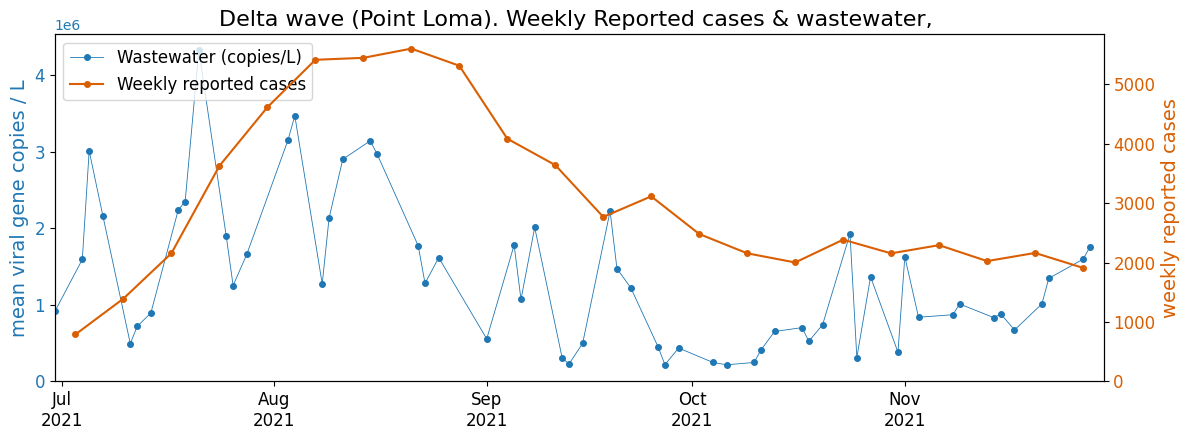

In [14]:
fig, ax = plt.subplots(figsize=(12, 4.5))

# Left axis: wastewater
c_ww = "tab:blue"
l1, = ax.plot(df_delta_ww["Sample_Date"], df_delta_ww["ww_copies_per_L"], ".-", ms=8, lw=0.6,
              color=c_ww, label="Wastewater (copies/L)")
ax.set_ylabel("mean viral gene copies / L", color=c_ww, fontsize=14)
ax.tick_params(axis="y", labelcolor=c_ww, labelsize=12)
ax.set_ylim(bottom=0)

# Right axis: weekly cases, plotted at the middle of each week
ax2 = ax.twinx()
c_cases = "#D95F02"
l2, = ax2.plot(df_delta["week_mid"], df_delta["weekly_total"], "o-", ms=4, lw=1.5,
               color=c_cases, label="Weekly reported cases")
ax2.set_ylabel("weekly reported cases", color=c_cases, fontsize=14)
ax2.tick_params(axis="y", labelcolor=c_cases, labelsize=12)
ax2.set_ylim(bottom=0)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.tick_params(axis="x", labelsize=12)
ax.set_xlim(FIT_START, FIT_END)

ax.set_title("Delta wave (Point Loma). Weekly Reported cases & wastewater, ", fontsize=16)
ax.legend(handles=[l1, l2], loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()

## 3. Setup 

## Setup Simulation

## Step 1: Variants

In [11]:
#VARIANT SHARE
VARIANT_SHARE_PL = {"delta": 0.78,
                 "alpha": 0.12,
                   "gamma": 0.06,
                     "wild_other": 0.04}

In [12]:
#MAKE VARIANTS
def make_variants(pop_infected):
    """Split one total number of starting infections into the four variant groups."""

    # Step 1: how many agents each variant gets (share x total, rounded to whole agents)
    n_delta      = int(round(VARIANT_SHARE_PL["delta"]      * pop_infected))   # 0.78 x 100 = 78
    n_alpha      = int(round(VARIANT_SHARE_PL["alpha"]      * pop_infected))   # 0.12 x 100 = 12
    n_gamma      = int(round(VARIANT_SHARE_PL["gamma"]      * pop_infected))   # 0.06 x 100 = 6
    n_wild_other = int(round(VARIANT_SHARE_PL["wild_other"] * pop_infected))   # 0.04 x 100 = 4

    # Step 2: rounding can leave the total 1-2 agents off, so wild/other absorbs the difference
    n_wild_other = pop_infected - (n_delta + n_alpha + n_gamma)                # 100 - 96 = 4

    # Step 3: one cv.variant object per variant, all imported on day 0
    delta = cv.variant("delta", days=0, n_imports=n_delta)    # e.g. n_imports=78
    alpha = cv.variant("alpha", days=0, n_imports=n_alpha)    # e.g. n_imports=12
    gamma = cv.variant("gamma", days=0, n_imports=n_gamma)    # e.g. n_imports=6

    # Wild/other has no cv.variant object: it is the sim's own pop_infected (e.g. 4)
    variants = [alpha, gamma, delta]

    # Print the table so the split is visible every time it runs
    print(f"total starting infections = {pop_infected}")
    print(f"  delta       : share {VARIANT_SHARE_PL['delta']:.2f} -> {n_delta:>4}  -> cv.variant('delta', days=0, n_imports={n_delta})")
    print(f"  alpha       : share {VARIANT_SHARE_PL['alpha']:.2f} -> {n_alpha:>4}  -> cv.variant('alpha', days=0, n_imports={n_alpha})")
    print(f"  gamma       : share {VARIANT_SHARE_PL['gamma']:.2f} -> {n_gamma:>4}  -> cv.variant('gamma', days=0, n_imports={n_gamma})")
    print(f"  wild/other  : share {VARIANT_SHARE_PL['wild_other']:.2f} -> {n_wild_other:>4}  -> cv.Sim(pop_infected={n_wild_other})")

    return variants, n_wild_other

In [13]:
variants, n_wild_other = make_variants(100)

total starting infections = 100
  delta       : share 0.78 ->   78  -> cv.variant('delta', days=0, n_imports=78)
  alpha       : share 0.12 ->   12  -> cv.variant('alpha', days=0, n_imports=12)
  gamma       : share 0.06 ->    6  -> cv.variant('gamma', days=0, n_imports=6)
  wild/other  : share 0.04 ->    4  -> cv.Sim(pop_infected=4)


### Population parameters

In [6]:
# --- Computational choices (kept) ---------------------------------------
POP_SIZE      = 50000
CATCHMENT_POP = 2116170                 # Point Loma catchment, from cases.csv
POP_SCALE     = CATCHMENT_POP / POP_SIZE  # real people per agent
N_RUNS        = 100

In [ ]:
# --- Window ---------------------------------------------------------------
START_DAY = "2021-06-28"                  # start of the Delta window
END_DAY   = "2021-11-30"
SCORE_START = pd.Timestamp("2021-06-30")

## Sim 1: With Strains only - Does Delta take-over

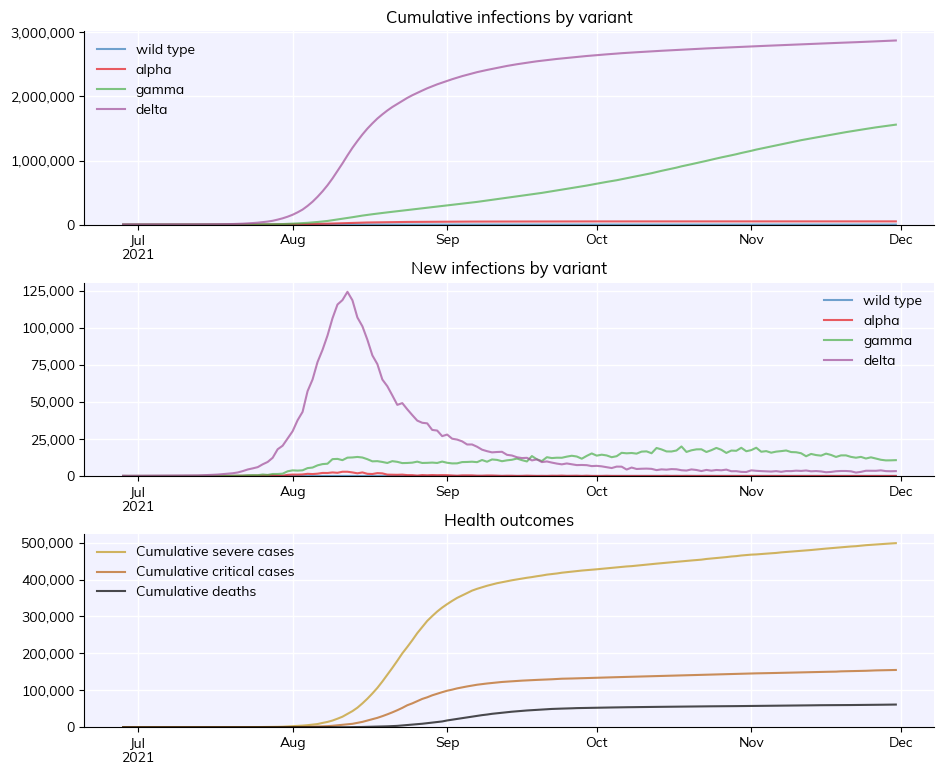

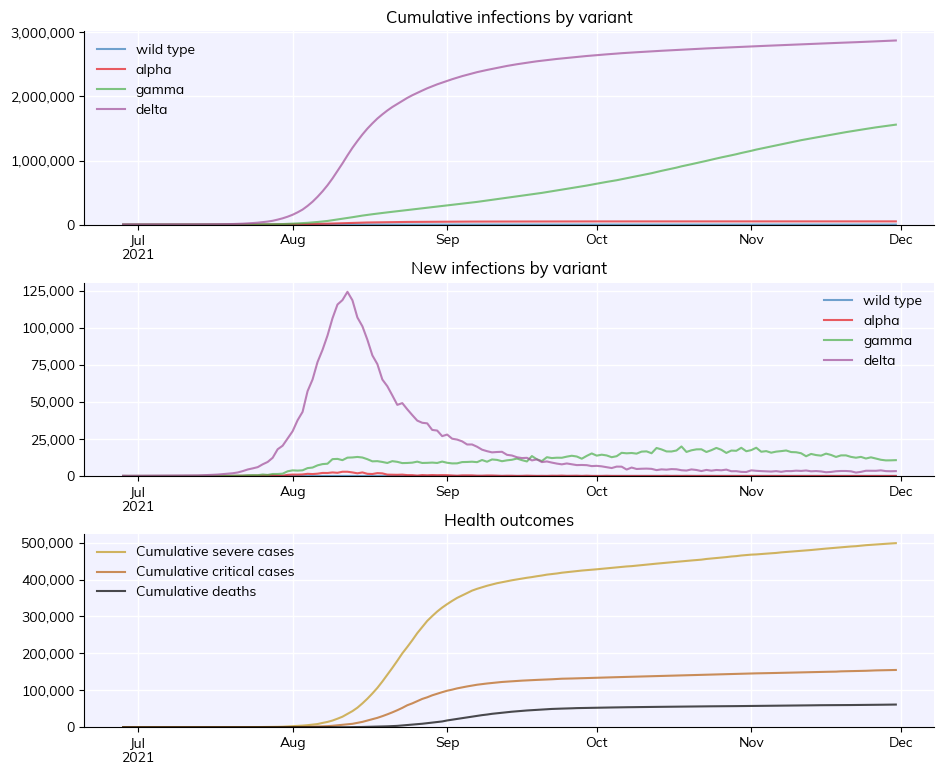

In [14]:
sim = cv.Sim(
    pop_size=POP_SIZE,
    pop_scale=POP_SCALE,
    pop_type="hybrid",
    location="usa",
    pop_infected=n_wild_other,     # wild/other seeds (4 of the 100)
    n_imports=0,                   # no other imports
    start_day=START_DAY,
    end_day=END_DAY,
    variants=variants,             # alpha, gamma, delta imported on day 0
    use_waning=True,               # needed for variants to interact
    verbose=0,
)
sim.run()
sim.plot("variant")

## Sim 2: Add vaccination counts

In [15]:
POP_COUNTY = 3347827
pl_share_one_dose_0630 = 2190000 / POP_COUNTY      # 0.654
pl_share_one_dose_0901 = 2407528 / POP_COUNTY      # 0.719

# Uptake among the unvaccinated: fraction with no dose on 30 Jun who had a first dose by 1 Sep
pl_uptake_unvacc = (pl_share_one_dose_0901 - pl_share_one_dose_0630) / (1 - pl_share_one_dose_0630)
print(pl_share_one_dose_0630, pl_uptake_unvacc)      # 0.654, 0.188

0.6541556657497535 0.1878760816598682


In [16]:
def make_vaccination(vacc_start_days, pfizer_share,
                     share_before=pl_share_one_dose_0630,
                     uptake_unvacc=pl_uptake_unvacc,
                     days_during=65):
    """Historical first-dose campaigns for Point Loma.

    vacc_start_days : days before 28 Jun when the campaign begins (RANGE 75-170, timing unknown)
    pfizer_share    : share of doses that are Pfizer (RANGE 0.50-0.65); the rest is Moderna
    share_before    : share of ALL residents with >=1 dose on 30 Jun (county, 0.654)
    uptake_unvacc   : fraction of the unvaccinated first-dosed 28 Jun -> 1 Sep (0.188)
    days_during     : length of that period in days (65)
    """
    days_before = np.arange(-int(vacc_start_days), 0)
    days_after  = np.arange(0, days_during)

    campaigns = []
    for brand, share in (("pfizer", pfizer_share), ("moderna", 1 - pfizer_share)):
        p_before = cv.historical_vaccinate_prob.estimate_prob(len(days_before), share_before * share)
        p_during = cv.historical_vaccinate_prob.estimate_prob(len(days_after), uptake_unvacc * share)
        campaigns.append(cv.historical_vaccinate_prob(vaccine=brand, days=days_before, prob=float(p_before)))
        campaigns.append(cv.historical_vaccinate_prob(vaccine=brand, days=days_after, prob=float(p_during)))
    return campaigns

In [20]:
def brand_coverages(total, pfizer_share):
    """Coverage each brand's campaign needs so that the UNION reaches `total`.
    Campaigns pick people independently, so the second one is sized on what's left."""
    c_pfizer  = total * pfizer_share
    c_moderna = 1 - (1 - total) / (1 - c_pfizer)      # makes 1 - (1-c1)(1-c2) = total
    return c_pfizer, c_moderna

def make_vaccination(vacc_start_days, pfizer_share,
                     share_before=pl_share_one_dose_0630,
                     uptake_unvacc=pl_uptake_unvacc,
                     days_during=65):
    days_before = np.arange(-int(vacc_start_days), 0)
    days_after  = np.arange(0, days_during)

    cov_before = brand_coverages(share_before, pfizer_share)     # (pfizer, moderna)
    cov_during = brand_coverages(uptake_unvacc, pfizer_share)

    campaigns = []
    for i, brand in enumerate(("pfizer", "moderna")):
        p_before = cv.historical_vaccinate_prob.estimate_prob(len(days_before), cov_before[i])
        p_during = cv.historical_vaccinate_prob.estimate_prob(len(days_after),  cov_during[i])
        campaigns.append(cv.historical_vaccinate_prob(vaccine=brand, days=days_before, prob=float(p_before)))
        campaigns.append(cv.historical_vaccinate_prob(vaccine=brand, days=days_after,  prob=float(p_during)))
    return campaigns

### Simulate

total starting infections = 100
  delta       : share 0.78 ->   78  -> cv.variant('delta', days=0, n_imports=78)
  alpha       : share 0.12 ->   12  -> cv.variant('alpha', days=0, n_imports=12)
  gamma       : share 0.06 ->    6  -> cv.variant('gamma', days=0, n_imports=6)
  wild/other  : share 0.04 ->    4  -> cv.Sim(pop_infected=4)


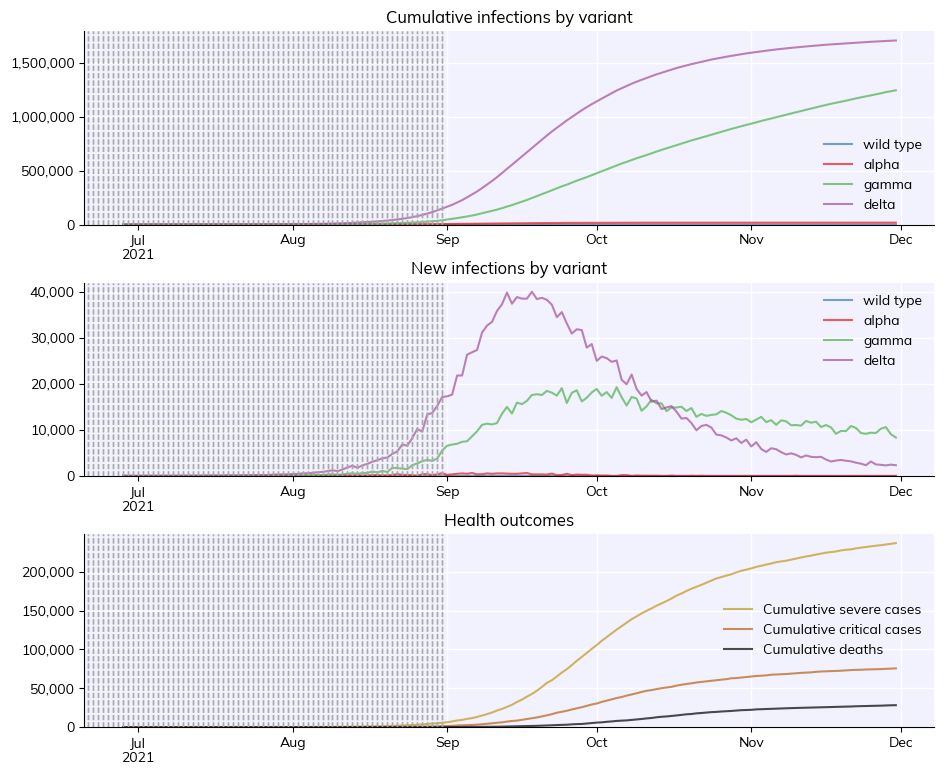

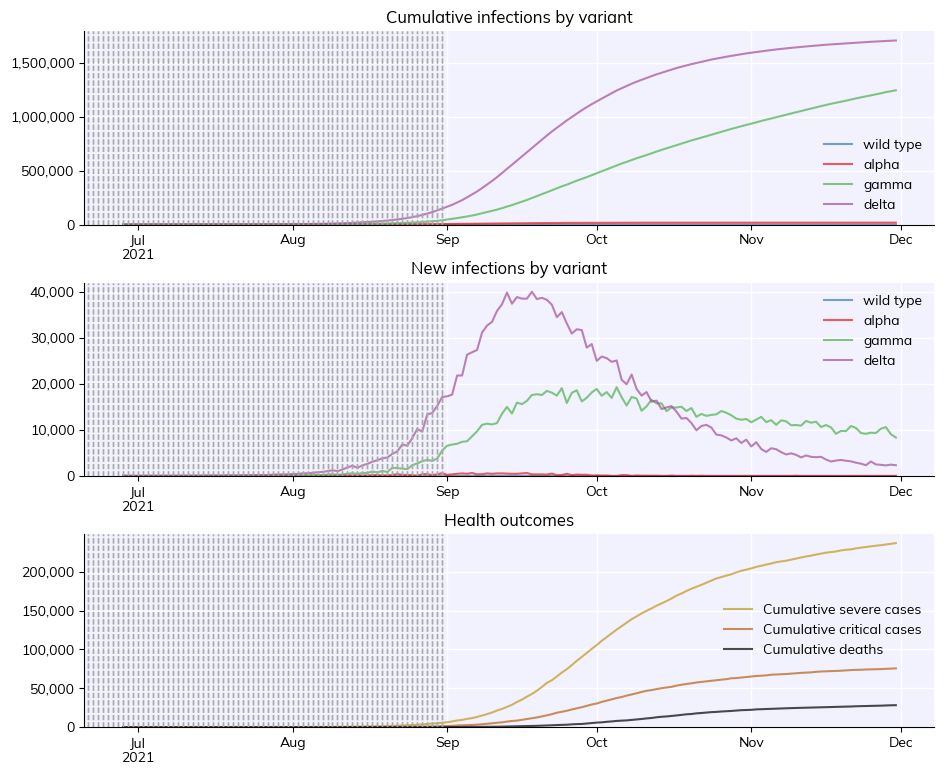

In [21]:
# Sim
vaccination = make_vaccination(vacc_start_days=120, pfizer_share=0.60)

variants, n_wild_other = make_variants(100)

sim = cv.Sim(
    pop_size=POP_SIZE, pop_scale=POP_SCALE, pop_type="hybrid", location="usa",
    pop_infected=n_wild_other, n_imports=0,
    start_day=START_DAY, end_day=END_DAY,
    variants=variants, use_waning=True,
    interventions=vaccination,            # new
    verbose=0,
)
sim.run()
sim.plot("variant")

In [22]:
def quick(label, beta=0.016, shares=None, total=100):
    shares = shares or VARIANT_SHARE_PL
    named = ("alpha", "gamma", "delta")
    n = {k: int(round(shares[k] * total)) for k in named}
    n_wild = total - sum(n.values())
    vs = [cv.variant(k, days=0, n_imports=n[k]) for k in named if n[k] > 0]
    s = cv.Sim(pop_size=POP_SIZE, pop_scale=POP_SCALE, pop_type="hybrid", location="usa",
               beta=beta, pop_infected=n_wild, n_imports=0, start_day=START_DAY, end_day=END_DAY,
               variants=vs, use_waning=True, interventions=make_vaccination(120, 0.60), verbose=0)
    s.run()
    peak = s.results["new_infections"].values.max()
    cum = s.results["cum_infections"].values[-1] / CATCHMENT_POP
    print(f"{label:<28} peak {peak:>9,.0f}/day   cumulative {cum:5.2f} x catchment")

delta_only = {"delta": 0.96, "alpha": 0.0, "gamma": 0.0, "wild_other": 0.04}

quick("current setup")
quick("delta only (no gamma)", shares=delta_only)
quick("beta 0.010", beta=0.010)
quick("beta 0.008", beta=0.008)
quick("delta only, beta 0.010", beta=0.010, shares=delta_only)

current setup                peak    57,856/day   cumulative  1.40 x catchment
delta only (no gamma)        peak    56,290/day   cumulative  1.07 x catchment
beta 0.010                   peak    30,557/day   cumulative  0.47 x catchment
beta 0.008                   peak     6,814/day   cumulative  0.07 x catchment
delta only, beta 0.010       peak    27,002/day   cumulative  0.59 x catchment


### Checks

In [19]:
chk = cv.Sim(pop_size=POP_SIZE, pop_scale=POP_SCALE, pop_type="hybrid", location="usa",
             start_day="2021-06-28", end_day="2021-06-29",     # 1 day, so n_days > 0
             use_waning=True,
             interventions=make_vaccination(120, 0.60), verbose=0)
chk.run()
print("2+ doses:", (chk.people.doses >= 2).mean(), "| 1+ dose:", (chk.people.doses >= 1).mean())

2+ doses: 0.46184 | 1+ dose: 0.5527


## Part 3: Add Testing

In [23]:
def make_testing(symp_prob, asymp_prob, test_delay):
    """Testing intervention: this is what turns infections into reported cases (new_diagnoses).
    symp_prob  : daily chance a symptomatic person is tested   (RANGE 0.02-0.30, unknown)
    asymp_prob : daily chance an asymptomatic person is tested (RANGE 0.0-0.01, unknown)
    test_delay : days from test to diagnosis                   (RANGE 1-4, unknown)
    """
    return cv.test_prob(symp_prob=symp_prob, asymp_prob=asymp_prob, test_delay=int(test_delay))

# Midpoints of the ranges, only so the first run works
testing = make_testing(symp_prob=0.077, asymp_prob=0.005, test_delay=2)

variants, n_wild_other = make_variants(100)

sim = cv.Sim(
    pop_size=POP_SIZE, pop_scale=POP_SCALE, pop_type="hybrid", location="usa",
    pop_infected=n_wild_other, n_imports=0,
    start_day=START_DAY, end_day=END_DAY,
    variants=variants, use_waning=True,
    interventions=[testing] + make_vaccination(120, 0.60),
    verbose=0,
)
sim.run()

total starting infections = 100
  delta       : share 0.78 ->   78  -> cv.variant('delta', days=0, n_imports=78)
  alpha       : share 0.12 ->   12  -> cv.variant('alpha', days=0, n_imports=12)
  gamma       : share 0.06 ->    6  -> cv.variant('gamma', days=0, n_imports=6)
  wild/other  : share 0.04 ->    4  -> cv.Sim(pop_infected=4)


Sim(<no label>; 2021-06-28 to 2021-11-30; pop: 50000 hybrid; epi: 2.64812e+06⚙, 26651.5☠)

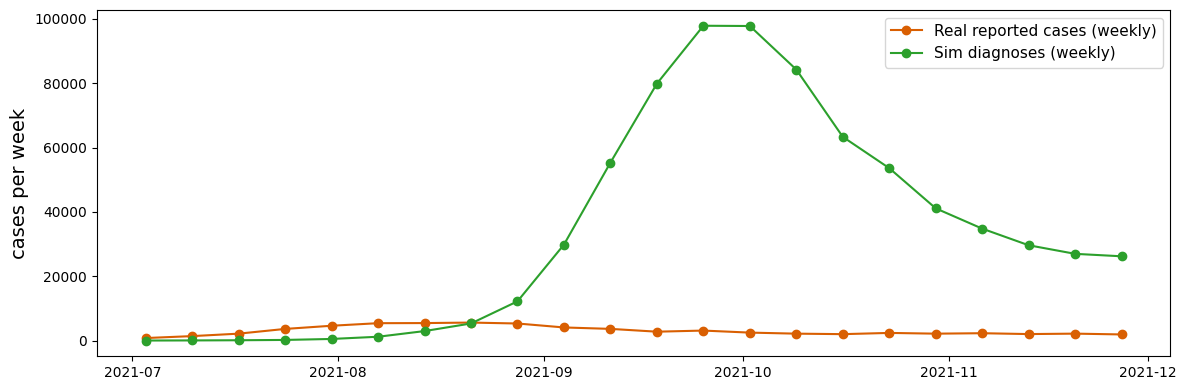

22 weeks | real total 67,523 | sim diagnoses 742,996
implied ascertainment: 0.28  (diagnoses / infections)


In [24]:
def plot_diagnoses(sim):
    """Weekly sim diagnoses vs real reported cases, on the same reporting weeks."""
    wk = df_pl_weekly[(df_pl_weekly["week_start"] >= START_DAY) &
                      (df_pl_weekly["week_end"] <= END_DAY)]

    daily = pd.Series(sim.results["new_diagnoses"].values, index=pd.to_datetime(sim.datevec))
    sim_weekly = [daily.loc[a:b].sum() for a, b in zip(wk["week_start"], wk["week_end"])]

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(wk["week_mid"], wk["weekly_total"], "o-", color="#D95F02", label="Real reported cases (weekly)")
    ax.plot(wk["week_mid"], sim_weekly, "o-", color="tab:green", label="Sim diagnoses (weekly)")
    ax.set_ylabel("cases per week", fontsize=14)
    ax.legend(fontsize=11)
    plt.tight_layout(); plt.show()

    # Ascertainment is an OUTPUT of the testing settings, not an input
    inf = sim.results["cum_infections"].values[-1]
    dia = sim.results["cum_diagnoses"].values[-1]
    print(f"{len(wk)} weeks | real total {wk['weekly_total'].sum():,.0f} | sim diagnoses {sum(sim_weekly):,.0f}")
    print(f"implied ascertainment: {dia / max(inf, 1):.2f}  (diagnoses / infections)")

plot_diagnoses(sim)

In [ ]:
def plot_diagnoses(sim):
    """Weekly sim diagnoses vs real reported cases, on the same reporting weeks."""
    wk = df_pl_weekly[(df_pl_weekly["week_start"] >= START_DAY) &
                      (df_pl_weekly["week_end"] <= END_DAY)]

    daily = pd.Series(sim.results["new_diagnoses"].values, index=pd.to_datetime(sim.datevec))
    sim_weekly = [daily.loc[a:b].sum() for a, b in zip(wk["week_start"], wk["week_end"])]

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(wk["week_mid"], wk["weekly_total"], "o-", color="#D95F02", label="Real reported cases (weekly)")
    ax.plot(wk["week_mid"], sim_weekly, "o-", color="tab:green", label="Sim diagnoses (weekly)")
    ax.set_ylabel("cases per week", fontsize=14)
    ax.legend(fontsize=11)
    plt.tight_layout(); plt.show()

    # Ascertainment is an OUTPUT of the testing settings, not an input
    inf = sim.results["cum_infections"].values[-1]
    dia = sim.results["cum_diagnoses"].values[-1]
    print(f"{len(wk)} weeks | real total {wk['weekly_total'].sum():,.0f} | sim diagnoses {sum(sim_weekly):,.0f}")
    print(f"implied ascertainment: {dia / max(inf, 1):.2f}  (diagnoses / infections)")

plot_diagnoses(sim)

## Draft 

In [ ]:
# Epsilon (1-3%) is not built in; folded into wild/other.

# --- Initial infections ----------------------------------------------------
ASCERTAINMENT = None                      # TODO: assumed fraction of infections reported (assumption, justify)
DURATION      = None                      # TODO: mean infectious days, from the timing parameters
N_INITIAL = None                          # TODO: total initial infected agents (estimate below, then let the fit adjust)

# Helper: estimate N_INITIAL from the first weekly case total
# first_week = df_pl_weekly.iloc[0]["weekly_total"]  (week starting 2021-06-30)
# N_INITIAL = int(round(first_week / 7 / ASCERTAINMENT * DURATION / POP_SCALE))

# --- Transmission ------------------------------------------------------------
BETA = 0.016                              # Covasim baseline; variant rel_beta does the work (check with cv.Sim().pars["beta"])

# --- Population immunity (look up; needed for use_waning) -----------------------
VACC_COVERAGE   = None                    # TODO: San Diego vaccination coverage, late June 2021, by age
VACC_PRODUCT    = None                    # TODO: efficacy vs Delta (infection), from literature
PRIOR_INFECTION = None                    # TODO: share previously infected by June 2021 (winter wave)

# --- Interventions (look up dates) -----------------------------------------------
REOPENING_DAY   = "2021-06-15"            # California reopening; check effect and date
REOPENING_BETA  = None                    # TODO: contact change after reopening (infer or justify)

# --- Testing (look up / justify) ------------------------------------------------------
BASELINE = dict(
    symp_prob=None,                       # TODO: infer; constrain with implied ascertainment
    asymp_prob=None,                      # TODO: justify (small)
    test_delay=None,                      # TODO: San Diego test turnaround in mid-2021
)
ISO_FACTOR = dict(h=None, s=None, w=None, c=None)   # TODO: isolation effect on contacts

# --- Disease timing (look up) -------------------------------------------------------------
# exp2inf, inf2sym, asym2rec, mild2rec, share asymptomatic: fill from the literature.
# Note: these are for the wild/Alpha/Delta period, not Omicron.

In [8]:
# Vaccintation
RANGES["pfizer_share"] = (0.50, 0.65)       # share of mRNA first doses; all-time dose split gives 0.60
MIDPOINT["pfizer_share"] = 0.60
# Moderna = 1 - pfizer_share. J&J (~5% of vaccinated people by my estimate) is still left out.

NameError: name 'RANGES' is not defined

In [ ]:
#One dose
JJ_SHARE = 0.05                              # TODO: ranged, estimate from dose counts / 2 for two-dose brands
shares = {"pfizer": (1 - JJ_SHARE) * p["pfizer_share"],
          "moderna": (1 - JJ_SHARE) * (1 - p["pfizer_share"]),
          "jj": JJ_SHARE}